**Implementación de modelos supervisados (clasificación/regresión) con Scikit-learn.**

### Importe de librerías necesarias


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import sys

# Ensure local src/ is on sys.path for notebook imports
project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from preprocesamiento.data_preprocessing import CorrelationFilter
from preprocesamiento.data_preprocessing import FeatureEngineeringRegression
from preprocesamiento.data_preprocessing import Winsorizer
from preprocesamiento.data_preprocessing import tratar_duplicados
from preprocesamiento.data_preprocessing import DataFrameConverter

from model_evaluation import evaluar_classifier

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler, MinMaxScaler

# from sklearn.compose import TransformedTargetRegressor


### Carga de Datos

In [3]:
url = "https://raw.githubusercontent.com/Octaviochavez/analitica_clientes/main/data/dataset_clientes.csv"
data = pd.read_csv(url)
data

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,4925,2021-08-09,47,Femenino,Centro,Divorciado,4.818457e+05,523321.283921,1.750852e+06,715.276140,...,39,Alto,Basico,1,0,Web,Viernes,4,5831,0
20396,1627,2021-10-26,18,Masculino,Sur,Divorciado,1.062000e+06,692112.449676,1.865442e+06,662.855074,...,319,Bajo,Premium,3,0,Web,Domingo,17,2925,0
20397,13007,2022-10-05,76,Femenino,Norte,Soltero,1.595617e+06,568544.699045,1.862204e+06,640.595219,...,325,Medio,Estandar,4,0,App,Viernes,16,1660,0
20398,17724,2020-01-10,23,Otro,Sur,Casado,8.056724e+05,348930.779211,2.032151e+06,466.372014,...,81,Bajo,Premium,2,0,Tienda,Lunes,14,4561,1


### Detección de inconsistencias

In [4]:
# Deteccion de inconsistencias: negativos o ceros en columnas que deberian ser positivas
columnas_negativas_check = [
    "ingreso_mensual", "gasto_mensual", "deuda_total", "score_crediticio",
    "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias",
    "num_productos", "hora_registro",
]
columnas_ceros_check = [
    "ingreso_mensual", "gasto_mensual", "deuda_total", "score_crediticio",
    "edad", "antiguedad_meses",
]

conteo_negativos = {}
conteo_ceros = {}
for col in columnas_negativas_check:
    if col in data.columns:
        conteo_negativos[col] = int((data[col] < 0).sum())
for col in columnas_ceros_check:
    if col in data.columns:
        conteo_ceros[col] = int((data[col] == 0).sum())

conteo_negativos = {k: v for k, v in conteo_negativos.items() if v > 0}
conteo_ceros = {k: v for k, v in conteo_ceros.items() if v > 0}

print("Negativos detectados:", conteo_negativos if conteo_negativos else "ninguno")
print("Ceros detectados:", conteo_ceros if conteo_ceros else "ninguno")

Negativos detectados: {'ingreso_mensual': 11, 'gasto_mensual': 68, 'deuda_total': 143}
Ceros detectados: ninguno


In [5]:
# Tratamiento: corrige valores negativos convirtiendolos a valor absoluto
columns_to_correct = [
    "ingreso_mensual", "gasto_mensual", "deuda_total", "score_crediticio",
    "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias",
    "num_productos", "hora_registro",
]

for col in columns_to_correct:
    if col in data.columns:
        data[col] = data[col].abs()

print("Valores negativos corregidos a valores absolutos en las columnas relevantes.")

Valores negativos corregidos a valores absolutos en las columnas relevantes.


### Construcción de arrays para procesamiento

In [6]:
numerical_features = ['porcentaje_gasto', "gasto_mensual", "score_crediticio", "ingreso_mensual", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas
categorical_nominales = ['abandono', "tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro","dia_semana_registro"] # Define listado de variables categóricas nominales
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora
orden_tipo_plan = ['Basico', 'Estandar', 'Premium'] # Define orden para variable ordinal tipo_plan
orden_uso_app = ['Bajo', 'Medio', 'Alto'] # Define orden para variable ordinal uso_app

### Pipelines para cada tipo de conjunto


In [7]:
# Define pipeline para variables numéricas
pipeline_numerical_features = Pipeline(steps=[
    ('winsorizer', Winsorizer(limits=(0.05, 0.05))), # Aplica Winsorización para limitar outliers al 5%
    ('imputer', SimpleImputer(strategy='mean')), # Imputa valores faltantes con el promedio
    ('scaler', StandardScaler()) # Escala características numéricas
])

In [8]:
# Define pipeline para variables categóricas nominales
pipeline_nominales = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputa valores faltantes con la moda
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Aplica codificación OneHotEncoder para variables nominales
])

In [9]:
# Define pipeline para variables categóricas ordinales
pipeline_ordinales = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputa valores faltantes con la moda
    ('ordinal', OrdinalEncoder(categories=[orden_tipo_plan, orden_uso_app])) # Aplica codificación OrdinalEncoder para variables ordinales con orden definido
])

### Integración de pipelines de transformación


In [10]:
# Combina pipelines para aplicar transformaciones específicas a cada tipo de variable
preprocesador = ColumnTransformer(
    transformers=[
        ('num_limpios', pipeline_numerical_features, numerical_features),
        ('cat_nom', pipeline_nominales, categorical_nominales),
        ('cat_ord', pipeline_ordinales, categorical_ordinales),
    ],
    remainder='drop' # Elimina columnas no especificadas
)

### Elimina duplicados y separa objetivo/features para mantener alineacion

In [11]:
data_sin_dup = tratar_duplicados(data, drop=True).reset_index(drop=True)
var_dep = data_sin_dup["deuda_total"].reset_index(drop=True)
var_indep = data_sin_dup.drop(columns=["deuda_total"])

# Modelo de regresión lineal (LinealRegression)

## Pipeline para Regresión Lineal

In [12]:
# modelo_con_logaritmo = TransformedTargetRegressor(
#     regressor = LinearRegression(),
#     func = np.log1p,                # Transformación de y en el fit
#     inverse_func = np.expm1         # Transformación inversa en el predict
# )

In [13]:
# Define pipeline de limpieza de datos que incluye eliminación de duplicados, ingeniería de características y preprocesamiento específico para cada tipo de variable
pipeline_limpieza = Pipeline(
    steps=[
        ("duplicados", FunctionTransformer(tratar_duplicados, kw_args={"drop": True})), # Elimina duplicados del dataset
        ("feature_engineering", FeatureEngineeringRegression()), # Agrega nuevas características
        ("preprocesamiento", preprocesador),
        ("conversion", DataFrameConverter(preprocesador)) # Convierte la salida a DataFrame con nombres
    ]
)

# Define pipeline para regresión lineal
pipeline_modelo_lr = Pipeline(
    steps = [
        ("colinealidad", CorrelationFilter(threshold = 0.9)), # Elimina variables altamente correlacionadas
        ("modelo", LinearRegression()) # Agrega modelo de regresión al pipeline
    ]
)

In [14]:
# Aplica pipeline de limpieza al dataset y obtiene el resultado transformado
data_transformada = pipeline_limpieza.fit_transform(var_indep)
data_transformada.columns = data_transformada.columns.str.replace("num_limpios__", "")
data_transformada.columns = data_transformada.columns.str.replace("cat_nom__", "")
data_transformada.columns = data_transformada.columns.str.replace("cat_ord__", "")
data_transformada["deuda_total"] = var_dep.to_numpy()
data_transformada.head()

,porcentaje_gasto,gasto_mensual,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app,deuda_total
0,8.917517e-02,0.849571,-1.481935,0.219473,0.979150,1.193186,-0.724598,1.653219,0.002765,1.535116,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2.448145e+06
1,-1.246435e+00,-0.584841,-0.260058,1.323554,0.139166,0.140295,-0.358339,1.186639,0.711810,-0.205888,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,1.620569e+06
2,4.360560e-16,-0.086265,1.738263,0.000000,-0.028831,-1.731512,0.374180,0.472486,0.711810,-0.786223,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,5.395040e+06
3,1.613845e+00,0.119750,-1.611474,-0.949411,0.307163,-1.643771,-1.273987,-0.165490,-0.706279,0.664614,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.999350e+06
4,4.649992e-01,0.623111,-1.351398,-0.220475,-0.980813,-1.351302,-0.907728,0.958110,0.002765,-0.496056,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.637711e+06


In [15]:
target = 'deuda_total'

In [16]:
X = data_transformada.drop(columns=[target])
y = data_transformada[target]

## División train/test


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

## Entrenamiento


In [18]:
pipeline_modelo_lr.fit(X_train, y_train)

c:\Users\david\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:420: UserWarning: Unknown section Parámetros
  self[section] = content
c:\Users\david\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:420: UserWarning: Unknown section Atributos
  self[section] = content


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('colinealidad', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,threshold,0.9
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
# Predicciones
y_pred = pipeline_modelo_lr.predict(X_test)

# Evaluación
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Métricas del modelo ---")

print(f"{'R2':<6}: {r2:.3f}")
print(f"{'MAE':<6}: {mae:,.0f}")


--- Métricas del modelo ---
R2    : -0.002
MAE   : 679,474


In [20]:
# Variables que fueron eliminadas por presentar colinealidad
pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_

['abandono_1', 'tiene_tarjeta_credito_1']

In [21]:
# Variables con las cuales fue entrenado el modelo
pipeline_limpieza.named_steps["conversion"].feature_names_

array(['num_limpios__porcentaje_gasto', 'num_limpios__gasto_mensual',
       'num_limpios__score_crediticio', 'num_limpios__ingreso_mensual',
       'num_limpios__edad', 'num_limpios__antiguedad_meses',
       'num_limpios__frecuencia_compra',
       'num_limpios__ultima_compra_dias', 'num_limpios__num_productos',
       'num_limpios__hora_registro', 'cat_nom__abandono_0',
       'cat_nom__abandono_1', 'cat_nom__tiene_tarjeta_credito_0',
       'cat_nom__tiene_tarjeta_credito_1', 'cat_nom__genero_Femenino',
       'cat_nom__genero_Masculino', 'cat_nom__genero_Otro',
       'cat_nom__region_Centro', 'cat_nom__region_Norte',
       'cat_nom__region_Sur', 'cat_nom__estado_civil_Casado',
       'cat_nom__estado_civil_Divorciado',
       'cat_nom__estado_civil_Soltero', 'cat_nom__canal_registro_App',
       'cat_nom__canal_registro_Tienda', 'cat_nom__canal_registro_Web',
       'cat_nom__dia_semana_registro_Domingo',
       'cat_nom__dia_semana_registro_Jueves',
       'cat_nom__dia_semana_

# Modelo DecisionTreeRegressor

## Pipeline para DecisionTreeRegressor

In [22]:
# Define pipeline de limpieza de datos que incluye eliminación de duplicados, ingeniería de características y preprocesamiento específico para cada tipo de variable
pipeline_limpieza = Pipeline(
    steps=[
        ("duplicados", FunctionTransformer(tratar_duplicados, kw_args={"drop": True})), # Elimina duplicados del dataset
        ("feature_engineering", FeatureEngineeringRegression()), # Agrega nuevas características
        ("preprocesamiento", preprocesador),
        ("conversion", DataFrameConverter(preprocesador)) # Convierte la salida a DataFrame con nombres
    ]
)

# Define pipeline para DecisionTreeRegressor
pipeline_modelo_dtr = Pipeline(
    steps = [
        ("colinealidad", CorrelationFilter(threshold = 0.9)), # Elimina variables altamente correlacionadas
        ("modelo", DecisionTreeRegressor(max_depth = 7, min_samples_leaf = 15, random_state = 42)) # Agrega modelo de regresión al pipeline
    ]
)

In [23]:
# Aplica pipeline de limpieza al dataset y obtiene el resultado transformado
data_transformada = pipeline_limpieza.fit_transform(var_indep)
data_transformada.columns = data_transformada.columns.str.replace("num_limpios__", "")
data_transformada.columns = data_transformada.columns.str.replace("cat_nom__", "")
data_transformada.columns = data_transformada.columns.str.replace("cat_ord__", "")
data_transformada["deuda_total"] = var_dep.to_numpy()
data_transformada.head()

,porcentaje_gasto,gasto_mensual,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app,deuda_total
0,8.917517e-02,0.849571,-1.481935,0.219473,0.979150,1.193186,-0.724598,1.653219,0.002765,1.535116,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2.448145e+06
1,-1.246435e+00,-0.584841,-0.260058,1.323554,0.139166,0.140295,-0.358339,1.186639,0.711810,-0.205888,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,1.620569e+06
2,4.360560e-16,-0.086265,1.738263,0.000000,-0.028831,-1.731512,0.374180,0.472486,0.711810,-0.786223,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,5.395040e+06
3,1.613845e+00,0.119750,-1.611474,-0.949411,0.307163,-1.643771,-1.273987,-0.165490,-0.706279,0.664614,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.999350e+06
4,4.649992e-01,0.623111,-1.351398,-0.220475,-0.980813,-1.351302,-0.907728,0.958110,0.002765,-0.496056,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.637711e+06


In [24]:
target = 'deuda_total'

In [25]:
X = data_transformada.drop(columns=[target])
y = data_transformada[target]

## División train/test


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

## Entrenamiento

In [27]:
pipeline_modelo_dtr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('colinealidad', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,threshold,0.9
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, th

In [28]:
# Predicciones
y_pred = pipeline_modelo_dtr.predict(X_test)

# Evaluación
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Métricas del modelo ---")

print(f"{'R2':<6}: {r2:.3f}")
print(f"{'MAE':<6}: {mae:,.0f}")


--- Métricas del modelo ---
R2    : -0.036
MAE   : 699,783


In [29]:
modelo_arbol = DecisionTreeRegressor(max_depth = 7, min_samples_leaf = 15, random_state = 42)
modelo_arbol = modelo_arbol.fit(X_train, y_train)

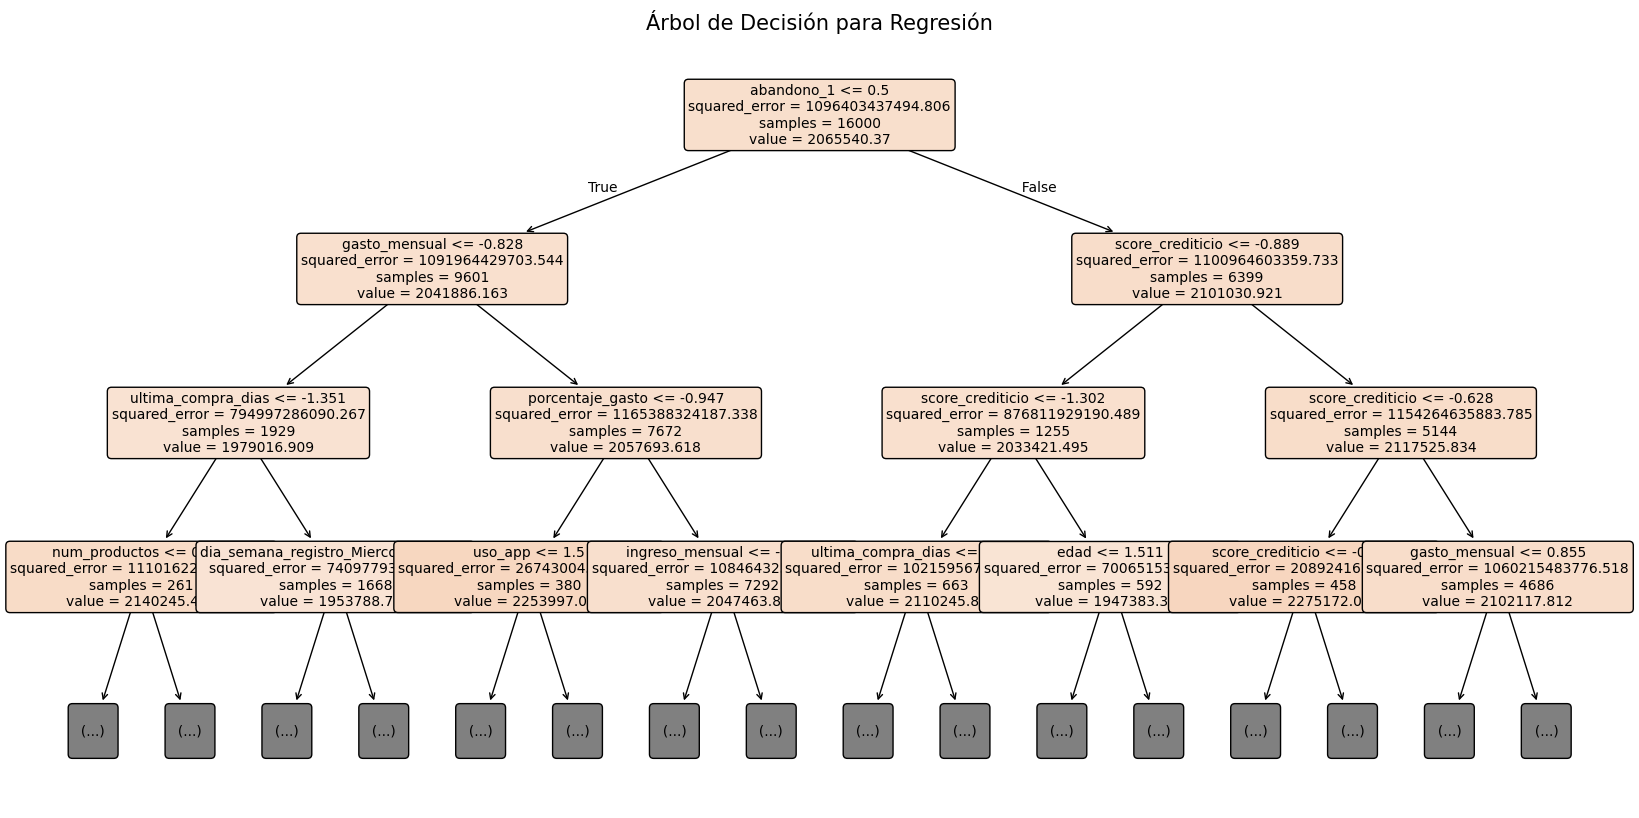

In [30]:
plt.figure(figsize=(20, 10))

# dibuja el árbol
plot_tree(modelo_arbol,
          feature_names=X_train.columns,  # Muestra los nombres reales de tus variables
          filled=True,
          rounded=True,
          fontsize=10,                    # Tamaño de la letra
          max_depth=3)                    # muestra solo los primeros 3 niveles

# mostrar el gráfico
plt.title("Árbol de Decisión para Regresión", fontsize=15)
plt.show()